# Neural Networks for Chaotic Dynamical Systems: The Hénon Map

Chaotic dynamical systems are deterministic — they follow exact mathematical rules — yet their long-term behaviour is practically unpredictable due to extreme sensitivity to initial conditions. The **Hénon map** is one of the most studied examples of a low-dimensional chaotic attractor. In this notebook we ask: *can a neural network learn the underlying dynamics of a chaotic system purely from data?*

We frame the problem as **supervised sequence prediction**: given the current state $(x_n, y_n)$, predict the next state $(x_{n+1}, y_{n+1})$. We generate training data by simulating many trajectories, train a fully-connected network with PyTorch, and then analyse both short-term accuracy and long-term attractor structure. Along the way we will see why chaos makes long-range prediction fundamentally hard — even for a perfect model.

## 1. Background: The Hénon Map

The Hénon map is a two-dimensional discrete-time dynamical system introduced by Michel Hénon in 1976. Starting from an initial condition $(x_0, y_0)$, each successive state is computed by:

$$x_{n+1} = 1 - a\,x_n^2 + y_n$$
$$y_{n+1} = b\,x_n$$

With the **classical parameters** $a = 1.4$ and $b = 0.3$ the system exhibits fully developed chaos: trajectories never repeat, but they remain confined to a fractal structure called the **Hénon attractor**.

### Why is this hard to predict?

The hallmark of chaos is **sensitive dependence on initial conditions**. Two trajectories that start a distance $\delta_0$ apart will — on average — diverge exponentially:

$$\delta_n \approx \delta_0\, e^{\lambda n}$$

where $\lambda > 0$ is the **Lyapunov exponent**. For the Hénon map $\lambda \approx 0.42$, meaning that errors roughly double every $\ln 2 / 0.42 \approx 1.6$ steps. This is why even a very accurate model will eventually produce trajectories that diverge from the true ones.

### What can a neural network learn?

Even though long-term prediction is impossible in principle, a neural network *can* learn the one-step mapping $(x_n, y_n) \mapsto (x_{n+1}, y_{n+1})$ very well. Moreover, when we iterate the learned model autonomously, the generated trajectories tend to stay on the attractor — capturing the **global statistical structure** of the chaos even when individual trajectories diverge.

## 2. Imports

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset, random_split
from sklearn.model_selection import train_test_split

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


## 3. Generating Training Data

A single long trajectory would over-represent parts of the attractor that happen to be visited more often. Instead, we simulate **$m = 1000$ trajectories of $n = 100$ steps** from different initial conditions spread across the basin of attraction.

Each consecutive pair of states becomes one training sample:

$$\text{input} = (x_n,\, y_n), \qquad \text{target} = (x_{n+1},\, y_{n+1})$$

This gives us $m \times (n-1) = 99{,}000$ input–output pairs — enough to cover the attractor densely.

In [2]:
a, b = 1.4, 0.3   # classical Hénon parameters
n = 100            # steps per trajectory
m = 1000           # number of initial conditions

X = np.zeros((m, n))
Y = np.zeros((m, n))

# Stratified initial conditions inside the attractor's basin
X[:, 0] = np.linspace(-0.75, 0.75, m)
Y[:, 0] = np.linspace(-0.75, 0.2,  m)

for i in range(1, n):
    X[:, i] = 1 - a * X[:, i-1]**2 + Y[:, i-1]
    Y[:, i] = b * X[:, i-1]

### Visualising the Hénon Attractor

Plotting all generated points reveals the characteristic banana-shaped fractal structure of the attractor. Points cluster along thin curved filaments — the self-similar signature of chaos.

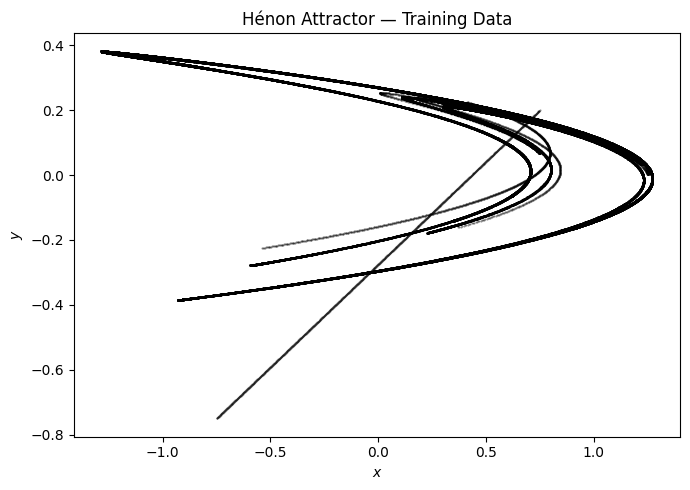

In [3]:
plt.figure(figsize=(7, 5))
plt.scatter(X.ravel(), Y.ravel(), s=0.3, color="black", alpha=0.4)
plt.title("Hénon Attractor — Training Data")
plt.xlabel("$x$")
plt.ylabel("$y$")
plt.tight_layout()
plt.show()

## 4. Building the Dataset

We reshape the arrays into flat lists of $(x_n, y_n)$ input pairs and $(x_{n+1}, y_{n+1})$ target pairs, then apply a standard 80/20 train/test split.

In [4]:
nn_input  = np.column_stack((X[:, :-1].ravel(), Y[:, :-1].ravel()))
nn_output = np.column_stack((X[:, 1:].ravel(),  Y[:, 1:].ravel()))

input_train, input_test, output_train, output_test = train_test_split(
    nn_input, nn_output, test_size=0.2, random_state=42
)

print(f"Training samples : {len(input_train):,}")
print(f"Test samples     : {len(input_test):,}")

Training samples : 79,200
Test samples     : 19,800


In [5]:
X_tr = torch.tensor(input_train,  dtype=torch.float32)
y_tr = torch.tensor(output_train, dtype=torch.float32)
X_te = torch.tensor(input_test,   dtype=torch.float32)
y_te = torch.tensor(output_test,  dtype=torch.float32)

full_train_ds = TensorDataset(X_tr, y_tr)

# Reserve 20% of training data for validation (early stopping monitor)
val_size = int(0.2 * len(full_train_ds))
tr_size  = len(full_train_ds) - val_size
tr_subset, val_subset = random_split(full_train_ds, [tr_size, val_size])

tr_loader  = DataLoader(tr_subset,  batch_size=128, shuffle=True)
val_loader = DataLoader(val_subset, batch_size=128)

## 5. Model Definition

We use a **fully-connected regression network** with four layers:

| Layer | Units | Activation |
|-------|-------|------------|
| Input | 2 | — |
| Hidden 1 | 64 | ReLU |
| Hidden 2 | 32 | ReLU |
| Hidden 3 | 16 | ReLU |
| Output | 2 | **Linear** |

The output layer is **linear** (no activation) because we are doing regression — predicting continuous coordinates, not class probabilities. The loss function is Mean Squared Error:

$$\mathcal{L} = \frac{1}{N} \sum_{i=1}^{N} \left\| \hat{\mathbf{s}}_i - \mathbf{s}_i \right\|^2$$

where $\mathbf{s}_i = (x_{n+1}, y_{n+1})$ is the true next state and $\hat{\mathbf{s}}_i$ is the network's prediction.

In [6]:
class HenonNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 64),  nn.ReLU(),
            nn.Linear(64, 32), nn.ReLU(),
            nn.Linear(32, 16), nn.ReLU(),
            nn.Linear(16, 2),
        )

    def forward(self, x):
        return self.net(x)


net = HenonNet().to(device)
total_params = sum(p.numel() for p in net.parameters())
print(f"Total trainable parameters: {total_params:,}")
print(net)

Total trainable parameters: 2,834
HenonNet(
  (net): Sequential(
    (0): Linear(in_features=2, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=16, bias=True)
    (5): ReLU()
    (6): Linear(in_features=16, out_features=2, bias=True)
  )
)


## 6. Training with Early Stopping

We train with the **Adam** optimiser (adaptive learning rates) and stop early if the validation loss does not improve for `patience = 10` consecutive epochs. At each epoch we track:

- **Training loss / MAE** — computed on the training mini-batches
- **Validation loss / MAE** — computed on the held-out validation split

When early stopping triggers, we restore the weights from the epoch with the best validation loss — this prevents overfitting.

In [7]:
MODEL_PATH = "henon_map.pt"

if os.path.exists(MODEL_PATH):
    net.load_state_dict(torch.load(MODEL_PATH, map_location=device))
    net.eval()
    model_loaded = True
    print("Pre-trained model loaded from disk.")
else:
    model_loaded = False

    optimizer = torch.optim.Adam(net.parameters())
    criterion = nn.MSELoss()

    n_epochs = 100
    patience  = 10
    best_val_loss   = float("inf")
    epochs_no_improve = 0
    best_state = None

    train_losses, val_losses = [], []
    train_maes,   val_maes   = [], []

    for epoch in range(n_epochs):
        # --- Training ---
        net.train()
        ep_loss, ep_mae = 0.0, 0.0
        for xb, yb in tr_loader:
            xb, yb = xb.to(device), yb.to(device)
            pred = net(xb)
            loss = criterion(pred, yb)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            ep_loss += loss.item() * len(xb)
            ep_mae  += (pred - yb).abs().mean().item() * len(xb)
        ep_loss /= tr_size
        ep_mae  /= tr_size

        # --- Validation ---
        net.eval()
        vl_loss, vl_mae = 0.0, 0.0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                pred = net(xb)
                vl_loss += criterion(pred, yb).item() * len(xb)
                vl_mae  += (pred - yb).abs().mean().item() * len(xb)
        vl_loss /= val_size
        vl_mae  /= val_size

        train_losses.append(ep_loss);  val_losses.append(vl_loss)
        train_maes.append(ep_mae);     val_maes.append(vl_mae)

        print(f"Epoch {epoch+1:3d}/{n_epochs} "
              f"| train_loss: {ep_loss:.5f}  val_loss: {vl_loss:.5f} "
              f"| train_mae: {ep_mae:.5f}  val_mae: {vl_mae:.5f}")

        # --- Early stopping ---
        if vl_loss < best_val_loss:
            best_val_loss = vl_loss
            best_state = {k: v.clone() for k, v in net.state_dict().items()}
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f"\nEarly stopping triggered at epoch {epoch+1}.")
                break

    net.load_state_dict(best_state)
    net.eval()
    torch.save(net.state_dict(), MODEL_PATH)
    print("\nModel saved.")

    # --- Test set evaluation ---
    with torch.no_grad():
        test_pred = net(X_te.to(device))
        test_loss = criterion(test_pred, y_te.to(device)).item()
        test_mae  = (test_pred - y_te.to(device)).abs().mean().item()
    print(f"Test loss: {test_loss:.5f}  |  Test MAE: {test_mae:.5f}")

Epoch   1/100 | train_loss: 0.03796  val_loss: 0.00022 | train_mae: 0.07316  val_mae: 0.00983
Epoch   2/100 | train_loss: 0.00011  val_loss: 0.00005 | train_mae: 0.00700  val_mae: 0.00493
Epoch   3/100 | train_loss: 0.00003  val_loss: 0.00002 | train_mae: 0.00413  val_mae: 0.00354
Epoch   4/100 | train_loss: 0.00002  val_loss: 0.00001 | train_mae: 0.00309  val_mae: 0.00270
Epoch   5/100 | train_loss: 0.00001  val_loss: 0.00001 | train_mae: 0.00263  val_mae: 0.00238
Epoch   6/100 | train_loss: 0.00001  val_loss: 0.00001 | train_mae: 0.00234  val_mae: 0.00221
Epoch   7/100 | train_loss: 0.00001  val_loss: 0.00001 | train_mae: 0.00229  val_mae: 0.00216
Epoch   8/100 | train_loss: 0.00001  val_loss: 0.00001 | train_mae: 0.00212  val_mae: 0.00196
Epoch   9/100 | train_loss: 0.00001  val_loss: 0.00001 | train_mae: 0.00220  val_mae: 0.00243
Epoch  10/100 | train_loss: 0.00001  val_loss: 0.00001 | train_mae: 0.00211  val_mae: 0.00182
Epoch  11/100 | train_loss: 0.00001  val_loss: 0.00001 | tra

## 7. Learning Curves

Plotting loss and MAE on a **logarithmic scale** makes it easy to see whether training has converged. Key things to look for:

- **Both curves descending together** → healthy training, no overfitting.
- **Validation curve rising while training curve falls** → overfitting; early stopping should have caught this.
- **Both curves plateauing** → the model has reached its capacity limit.

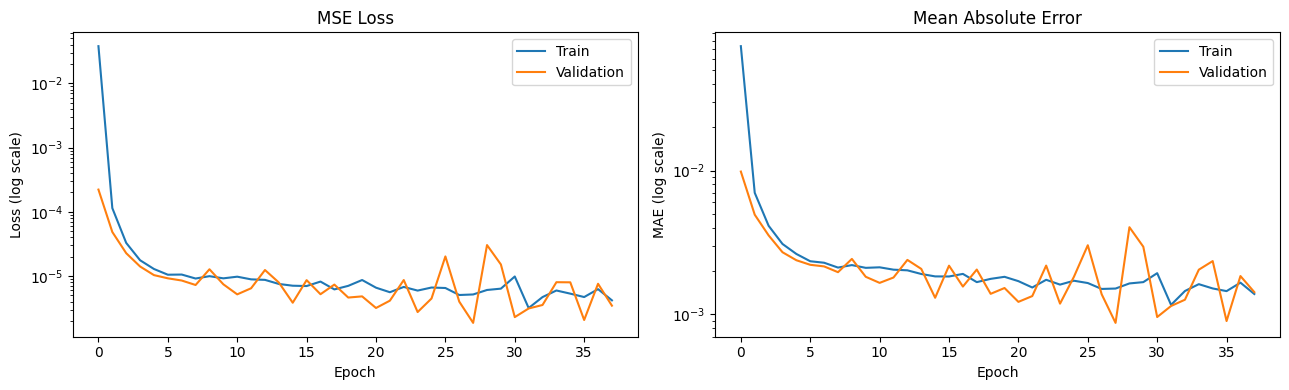

In [8]:
if not model_loaded:
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    axes[0].plot(train_losses, label="Train")
    axes[0].plot(val_losses,   label="Validation")
    axes[0].set_yscale("log")
    axes[0].set_title("MSE Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss (log scale)")
    axes[0].legend()

    axes[1].plot(train_maes, label="Train")
    axes[1].plot(val_maes,   label="Validation")
    axes[1].set_yscale("log")
    axes[1].set_title("Mean Absolute Error")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("MAE (log scale)")
    axes[1].legend()

    plt.tight_layout()
    plt.show()
else:
    print("Learning curves not available for a loaded model.")

## 8. Autoregressive Trajectory Prediction

Once trained, we use the network **autoregressively**: we feed it a single initial condition and iteratively feed its own output back as input to generate a full trajectory.

$$\hat{\mathbf{s}}_{n+1} = f_{\theta}(\hat{\mathbf{s}}_n), \qquad \hat{\mathbf{s}}_0 = (x_0, y_0)$$

Any small one-step error gets amplified by the Lyapunov exponent over successive steps — this is why short-term prediction is accurate but long-term prediction inevitably diverges, even for a well-trained model. This is a fundamental property of chaos, not a failure of the network.

In [9]:
np.random.seed(0)
X0 = np.random.uniform(-0.75, 0.75)
Y0 = np.random.uniform(-0.75, 0.2)

X_predict = np.zeros(n)
Y_predict = np.zeros(n)
X_predict[0], Y_predict[0] = X0, Y0

net.eval()
with torch.no_grad():
    for i in range(1, n):
        state = torch.tensor([[X_predict[i-1], Y_predict[i-1]]], dtype=torch.float32).to(device)
        pred  = net(state).cpu().numpy()
        X_predict[i] = pred[0, 0]
        Y_predict[i] = pred[0, 1]

# True trajectory from the exact Hénon equations
X_true = np.zeros(n)
Y_true = np.zeros(n)
X_true[0], Y_true[0] = X0, Y0
for i in range(1, n):
    X_true[i] = 1 - a * X_true[i-1]**2 + Y_true[i-1]
    Y_true[i] = b * X_true[i-1]

mse = np.mean((X_predict - X_true)**2 + (Y_predict - Y_true)**2)
print(f"Trajectory MSE (over {n} steps): {mse:.6f}")

Trajectory MSE (over 100 steps): 0.894369


## 9. Short-term vs Long-term Accuracy

We compare the first and last 20 steps of the predicted and true trajectories. The network should track the true trajectory closely at the start, with errors growing over time due to the positive Lyapunov exponent.

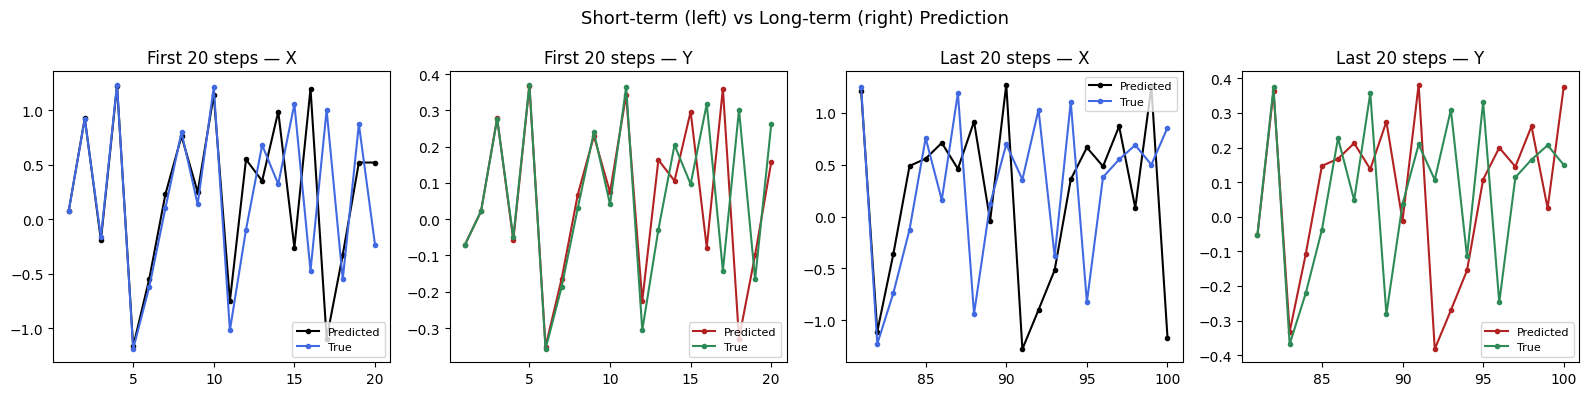

In [10]:
g = 20
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

axes[0].plot(range(1, g+1), X_predict[:g], "-o", ms=3, color="black", label="Predicted")
axes[0].plot(range(1, g+1), X_true[:g],    "-o", ms=3, color="royalblue", label="True")
axes[0].set_title(f"First {g} steps — X")
axes[0].legend(fontsize=8)

axes[1].plot(range(1, g+1), Y_predict[:g], "-o", ms=3, color="firebrick", label="Predicted")
axes[1].plot(range(1, g+1), Y_true[:g],    "-o", ms=3, color="seagreen",  label="True")
axes[1].set_title(f"First {g} steps — Y")
axes[1].legend(fontsize=8)

axes[2].plot(range(n-g+1, n+1), X_predict[-g:], "-o", ms=3, color="black",     label="Predicted")
axes[2].plot(range(n-g+1, n+1), X_true[-g:],    "-o", ms=3, color="royalblue", label="True")
axes[2].set_title(f"Last {g} steps — X")
axes[2].legend(fontsize=8)

axes[3].plot(range(n-g+1, n+1), Y_predict[-g:], "-o", ms=3, color="firebrick", label="Predicted")
axes[3].plot(range(n-g+1, n+1), Y_true[-g:],    "-o", ms=3, color="seagreen",  label="True")
axes[3].set_title(f"Last {g} steps — Y")
axes[3].legend(fontsize=8)

plt.suptitle("Short-term (left) vs Long-term (right) Prediction", fontsize=13)
plt.tight_layout()
plt.show()

## 10. Attractor Reconstruction

Although individual trajectories diverge, the network has internalised the *geometry* of the attractor. By iterating the model from a single starting point for many steps we can reconstruct the attractor shape — and compare it to the true one.

A good model should reproduce the characteristic banana shape and fractal filaments, even if no single predicted point matches the corresponding true point.

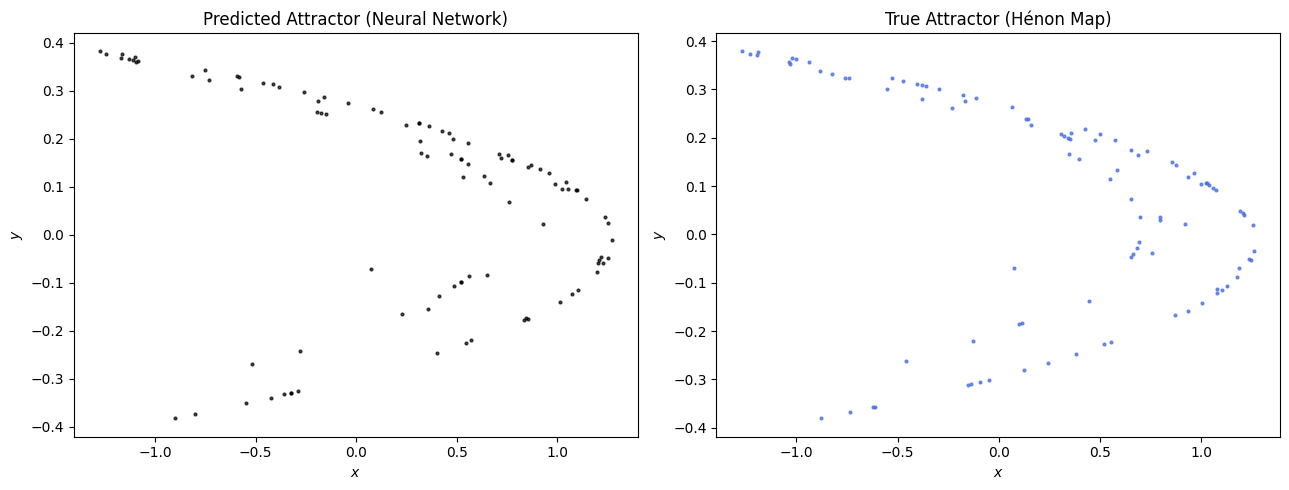

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(X_predict, Y_predict, s=4, color="black", alpha=0.7)
axes[0].set_title("Predicted Attractor (Neural Network)")
axes[0].set_xlabel("$x$")
axes[0].set_ylabel("$y$")

axes[1].scatter(X_true, Y_true, s=4, color="royalblue", alpha=0.7)
axes[1].set_title("True Attractor (Hénon Map)")
axes[1].set_xlabel("$x$")
axes[1].set_ylabel("$y$")

plt.tight_layout()
plt.show()

## 11. Summary and Key Takeaways

| | |
|---|---|
| **Task** | One-step regression: $(x_n, y_n) \to (x_{n+1}, y_{n+1})$ |
| **Architecture** | 4-layer MLP, ReLU activations, linear output |
| **Training** | Adam + MSE loss, early stopping on validation loss |
| **Short-term prediction** | Accurate — the network has learned the local dynamics |
| **Long-term prediction** | Diverges — unavoidable due to chaos ($\lambda > 0$) |
| **Attractor structure** | Recovered — the network has learned the global geometry |

### Why does the long-term prediction fail?

This is not a failure of the network — it is a mathematical impossibility. The Lyapunov exponent $\lambda \approx 0.42$ means that even a model error of $10^{-6}$ will grow to $\mathcal{O}(1)$ after roughly $6 \ln 10 / 0.42 \approx 33$ steps. No finite-precision model can overcome this.

### What has the network actually learned?

The network has learned the **invariant measure** of the attractor: the probability distribution over states that the Hénon map visits in the long run. This is why iterated predictions stay on the attractor even when they diverge from the true trajectory — the model has captured the *statistics* of chaos, not the individual trajectory.